Submitted by

Jamal Ahmad Khan (366394)

BESE-12B

# Lab 7: Open Ended Lab

In [47]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torchvision.transforms as transforms 
from torchvision.utils import make_grid  
from torchvision.datasets import ImageFolder
import tensorflow
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Flatten, Dense

# Exploring the data

In [48]:
# Paths to the directories
train_dir = '/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train'
valid_dir = '/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid'
test_dir = '/kaggle/input/new-plant-diseases-dataset/test/test'

## Training set

In [49]:
# Extracting the no. of unique plants and unique diseases
plants = []
number_of_diseases = 0
for plant in diseases:
    if plant.split('___')[0] not in plants:
        plants.append(plant.split('___')[0])
    if plant.split('___')[1] != 'healthy':
        number_of_diseases += 1

In [50]:
print("Number of unique plants: {}".format(len(plants)))
print("Number of unique diseases: {}".format(number_of_diseases))
print(f"Unique Plants are: \n{plants}")

Number of unique plants: 14
Number of unique diseases: 26
Unique Plants are: 
['Tomato', 'Grape', 'Orange', 'Soybean', 'Squash', 'Potato', 'Corn_(maize)', 'Strawberry', 'Peach', 'Apple', 'Blueberry', 'Cherry_(including_sour)', 'Pepper,_bell', 'Raspberry']


The dataset contains images of leaves from 14 different plant categories. Excluding healthy leaves, there are 26 types of images that depict specific diseases affecting specific plants.

In [51]:
# Number of images for each disease 
nums = {}
for disease in diseases:
    nums[disease] = len(os.listdir(train_dir + '/' + disease))

In [52]:
# Converting the nums dictionary to Pandas dataframe
img_per_class = pd.DataFrame(nums.values(), index=nums.keys(), columns=["no. of images"])
img_per_class

,no. of images
Tomato___Late_blight,1851
Tomato___healthy,1926
Grape___healthy,1692
Orange___Haunglongbing_(Citrus_greening),2010
Soybean___healthy,2022
Squash___Powdery_mildew,1736
Potato___healthy,1824
Corn_(maize)___Northern_Leaf_Blight,1908
Tomato___Early_blight,1920
Tomato___Septoria_leaf_spot,1745


Text(0.5, 1.0, 'Images per Class of Plant Disease')

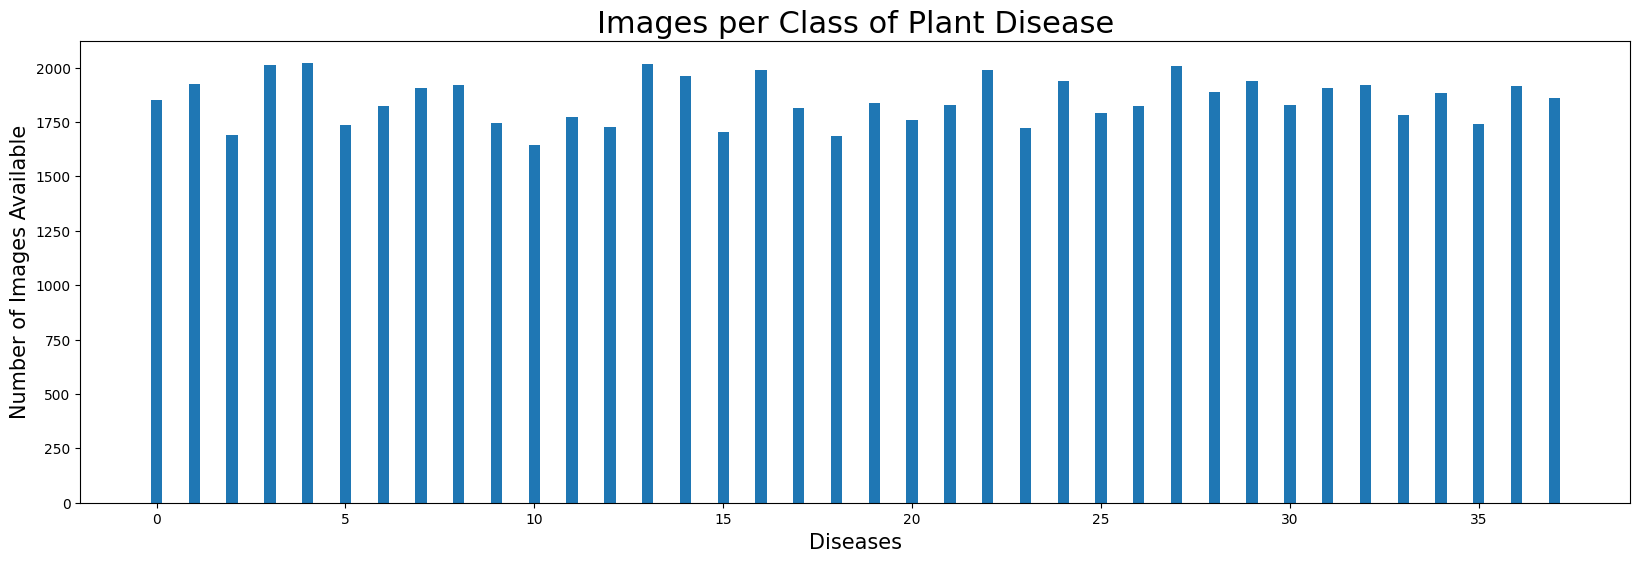

In [53]:
# Plotting no. of images available for each disease

index = [n for n in range(38)]
plt.figure(figsize=(20, 6))
plt.bar(index, [n for n in nums.values()], width=0.3)
plt.xlabel('Diseases', fontsize=15)
plt.ylabel('Number of Images Available', fontsize=15)
# plt.xticks(index, diseases, fontsize=5, rotation=90)
plt.title('Images per Class of Plant Disease', fontsize=22)

In [54]:
# Total no. of images in training set

n_train = 0
for value in nums.values():
    n_train += value
print(f"There are total {n_train} images in the training set.")

There are total 70295 images in the training set.


## Validation set

In [55]:
# Number of images for each disease 
nums = {}
for disease in diseases:
    nums[disease] = len(os.listdir(valid_dir + '/' + disease))

In [56]:
# Converting the nums dictionary to Pandas dataframe
img_per_class = pd.DataFrame(nums.values(), index=nums.keys(), columns=["no. of images"])
img_per_class

,no. of images
Tomato___Late_blight,463
Tomato___healthy,481
Grape___healthy,423
Orange___Haunglongbing_(Citrus_greening),503
Soybean___healthy,505
Squash___Powdery_mildew,434
Potato___healthy,456
Corn_(maize)___Northern_Leaf_Blight,477
Tomato___Early_blight,480
Tomato___Septoria_leaf_spot,436


Text(0.5, 1.0, 'Images per Class of Plant Disease')

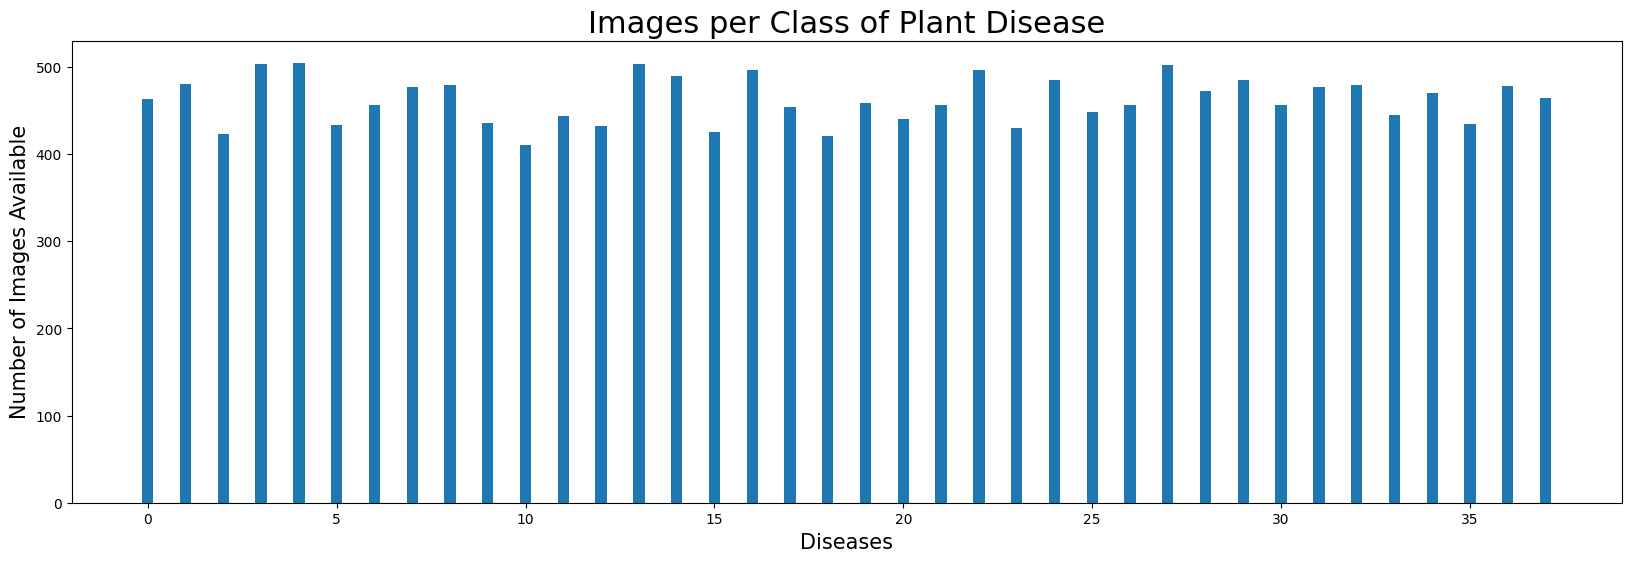

In [57]:
# Plotting no. of images available for each disease

index = [n for n in range(38)]
plt.figure(figsize=(20, 6))
plt.bar(index, [n for n in nums.values()], width=0.3)
plt.xlabel('Diseases', fontsize=15)
plt.ylabel('Number of Images Available', fontsize=15)
# plt.xticks(index, diseases, fontsize=5, rotation=90)
plt.title('Images per Class of Plant Disease', fontsize=22)

In [58]:
# Total no. of images in validation set

n_train = 0
for value in nums.values():
    n_train += value
print(f"There are total {n_train} images in the validation set.")

There are total 17572 images in the validation set.


## Test set

In [59]:
n_test = len(os.listdir(test_dir))
print(f"Total number of images in test set are {n_test}.")

Total number of images in test set are 33.


## Showing some images

In [60]:
# datasets for validation and training
train = ImageFolder(train_dir, transform=transforms.ToTensor())
valid = ImageFolder(valid_dir, transform=transforms.ToTensor()) 

In [61]:
# for checking some images from training dataset
def show_image(image, label):
    print("Label : " + train.classes[label] + "(" + str(label) + ")")
    plt.imshow(image.permute(1, 2, 0))

Label : Apple___Apple_scab(0)


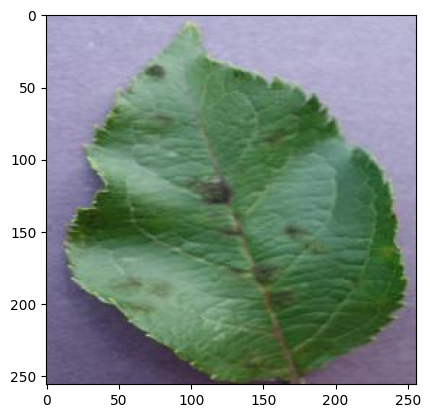

In [62]:
show_image(*train[0])

Label : Tomato___healthy(37)


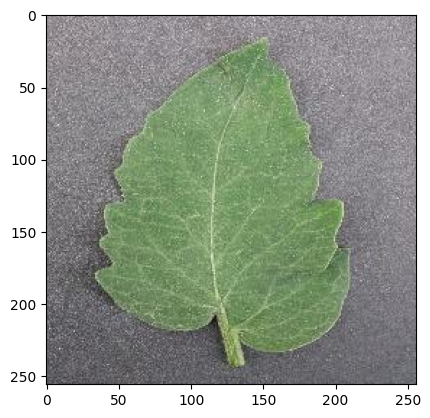

In [63]:
show_image(*train[70000])

Label : Peach___Bacterial_spot(16)


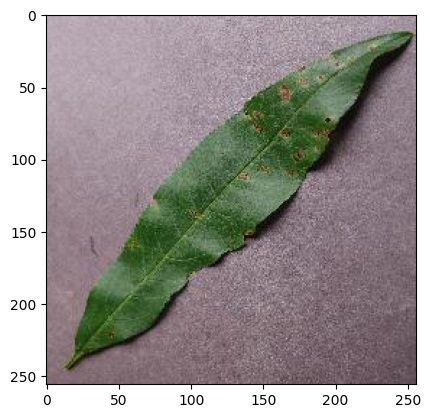

In [64]:
show_image(*train[30000])

# Data preprocessing

In [65]:
train_datagen = ImageDataGenerator(rescale=1./255,
                                   shear_range=0.2,
                                   zoom_range=0.2,
                                   width_shift_range=0.2,
                                   height_shift_range=0.2,
                                   fill_mode='nearest')

valid_datagen = ImageDataGenerator(rescale=1./255)

training_set = train_datagen.flow_from_directory(train_dir,
                                                 target_size=(224, 224),
                                                 batch_size=128,
                                                 class_mode='categorical')

valid_set = valid_datagen.flow_from_directory(valid_dir,
                                            target_size=(224, 224),
                                            batch_size=128,
                                            class_mode='categorical')

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.


# VGG16

In [66]:
# Data generators for training and validation
train_datagen = ImageDataGenerator(rescale=1./255,
                                   shear_range=0.2,
                                   zoom_range=0.2,
                                   width_shift_range=0.2,
                                   height_shift_range=0.2,
                                   fill_mode='nearest')

valid_datagen = ImageDataGenerator(rescale=1./255)

training_set = train_datagen.flow_from_directory(train_dir,
                                                 target_size=(224, 224),
                                                 batch_size=128,
                                                 class_mode='categorical')

valid_set = valid_datagen.flow_from_directory(valid_dir,
                                              target_size=(224, 224),
                                              batch_size=128,
                                              class_mode='categorical')

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.


In [67]:
# Define input layer
input_layer = Input(shape=(224, 224, 3))

# Load VGG16 without the top layers
base_model_1 = VGG16(include_top=False, input_tensor=input_layer)
base_model_1.trainable = False  # Freeze the base model layers

# Add custom layers on top of the VGG16 base
x = Flatten()(base_model_1.output)
output_layer = Dense(38, activation='softmax')(x)  # 38 output classes

# Define the model
classifier_1 = Model(inputs=input_layer, outputs=output_layer)

# Compile the model to finalize
classifier_1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [68]:
classifier_1.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 38)             │       953,382 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,668,070 (59.77 MB)

 Trainable params: 953,382 (3.64 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [69]:
history_1 = classifier_1.fit(training_set, validation_data = valid_set, epochs = 3)

Epoch 1/3


/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


550/550 ━━━━━━━━━━━━━━━━━━━━ 1606s 3s/step - accuracy: 0.6775 - loss: 1.1961 - val_accuracy: 0.8972 - val_loss: 0.3108
Epoch 2/3
550/550 ━━━━━━━━━━━━━━━━━━━━ 1194s 2s/step - accuracy: 0.8758 - loss: 0.3842 - val_accuracy: 0.9111 - val_loss: 0.2890
Epoch 3/3
550/550 ━━━━━━━━━━━━━━━━━━━━ 1182s 2s/step - accuracy: 0.8947 - loss: 0.3197 - val_accuracy: 0.9233 - val_loss: 0.2346


In [ ]:
# Saving our model
# filepath_1 = "vgg16.h5"
# classifier_1.save(filepath_1)

# Visualzing our performance metrics

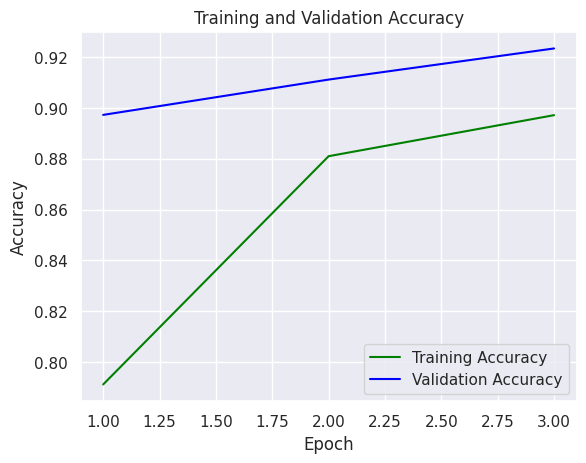

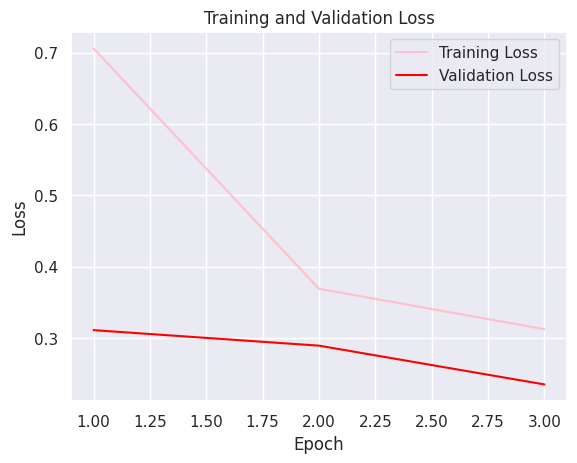

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

acc = history_1.history['accuracy']
val_acc = history_1.history['val_accuracy']
loss = history_1.history['loss']
val_loss = history_1.history['val_loss']
epochs = range(1, len(loss) + 1)

#accuracy plot
plt.plot(epochs, acc, color='green', label='Training Accuracy')
plt.plot(epochs, val_acc, color='blue', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.figure()
#loss plot
plt.plot(epochs, loss, color='pink', label='Training Loss')
plt.plot(epochs, val_loss, color='red', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Summary

